# 🔍 Análise Exploratória - Yellow Taxi NYC

## 🎯 Objetivo

Explorar os dados de corridas de táxi para identificar padrões, anomalias e insights de negócio.

---

## 📊 Análises Disponíveis:

1. Estatísticas descritivas
2. Distribuição de valores
3. Correlações
4. Análise temporal
5. Análise geográfica

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar visualizações
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [0]:
# Carregar tabela Silver
df = spark.table("workspace.silver.yellow_taxi_trips")

print(f"✅ Dados carregados: {df.count():,} registros")
print(f"✅ Período: {df.agg(F.min('tpep_pickup_datetime'), F.max('tpep_pickup_datetime')).collect()[0]}")

✅ Dados carregados: 15,342,765 registros
✅ Período: Row(min(tpep_pickup_datetime)=datetime.datetime(2023, 1, 1, 0, 0, 5), max(tpep_pickup_datetime)=datetime.datetime(2023, 5, 31, 23, 59, 56))


## 1️⃣ Estatísticas Descritivas

Visão geral dos principais campos numéricos.

In [0]:
# Estatísticas básicas
df.select(
    "passenger_count",
    "total_amount"
).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").display()

summary,passenger_count,total_amount
count,15342765,15342765
mean,1.3861719188164585,28.314257065717197
stddev,0.8815927058919338,22.502545126451533
min,1,0.0
25%,1,15.8
50%,1,20.64
75%,1,29.88
max,9,6304.9


## 2️⃣ Distribuição de Valores

Visualizar a distribuição dos valores de corridas.

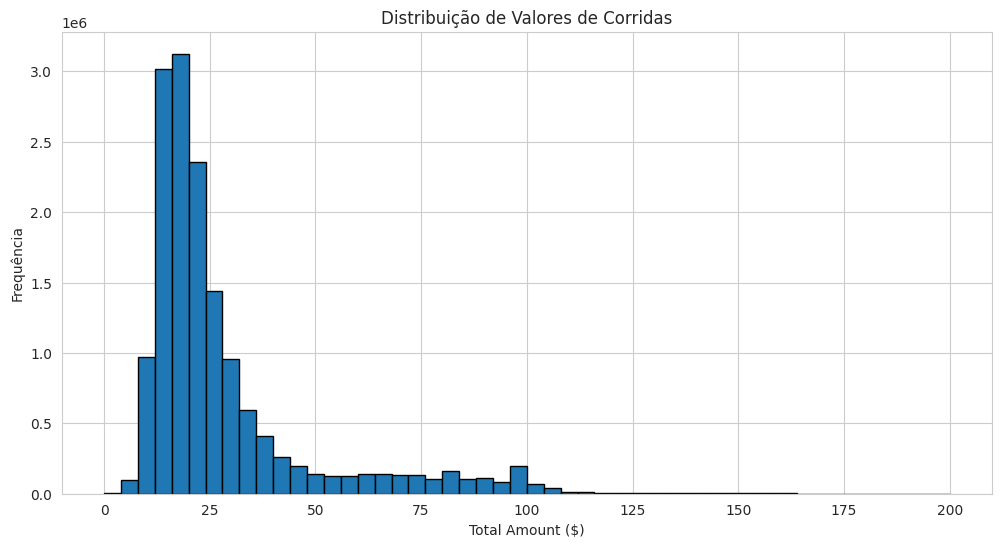

In [0]:
# Distribuição de valores (filtrar outliers para visualização)
df_viz = df.filter(
    (F.col("total_amount") > 0) & 
    (F.col("total_amount") < 200)
)

# Criar histograma
df_viz.select("total_amount").toPandas().hist(bins=50, edgecolor='black')
plt.xlabel("Total Amount ($)")
plt.ylabel("Frequência")
plt.title("Distribuição de Valores de Corridas")
plt.show()

## 3️⃣ Análise Temporal

Padrões ao longo do tempo.

In [0]:
# Corridas por dia da semana
df_dow = df.groupBy(
    F.dayofweek("tpep_pickup_datetime").alias("day_of_week")
).agg(
    F.count("*").alias("trip_count"),
    F.avg("total_amount").alias("avg_amount")
).orderBy("day_of_week")

df_dow.display()

day_of_week,trip_count,avg_amount
1,1945095,29.271704708514516
2,1912338,29.612045804667606
3,2231955,28.222553886618346
4,2379633,28.27115255167852
5,2358825,28.635902989840584
6,2287647,28.15481157713917
7,2227272,26.32490035344003


## 4️⃣ Top Corridas

Corridas mais caras e mais longas.

In [0]:
# Top 10 corridas mais caras
print("🏆 Top 10 Corridas Mais Caras")
print("=" * 50)

top_expensive = df.orderBy(F.col("total_amount").desc()).limit(10)
top_expensive.select(
    "tpep_pickup_datetime",
    "passenger_count",
    "total_amount"
).display()

# Estatísticas das top corridas
print("\n📊 Estatísticas das Top 10:")
top_stats = top_expensive.agg(
    F.avg("total_amount").alias("avg_amount"),
    F.avg("passenger_count").alias("avg_passengers")
).collect()[0]

print(f"  💰 Valor médio: ${top_stats['avg_amount']:.2f}")
print(f"  👥 Passageiros médios: {top_stats['avg_passengers']:.1f}")

🏆 Top 10 Corridas Mais Caras


tpep_pickup_datetime,passenger_count,total_amount
2023-05-16T10:12:28.000Z,6,6304.9
2023-04-06T14:08:51.000Z,2,2451.0
2023-02-08T23:44:44.000Z,1,2208.1
2023-05-23T21:04:24.000Z,1,1715.95
2023-01-24T12:43:44.000Z,1,1169.4
2023-05-24T14:20:32.000Z,1,1026.5
2023-05-13T15:29:32.000Z,2,1023.6
2023-05-07T15:15:08.000Z,1,1011.7
2023-03-04T09:30:52.000Z,1,1000.0
2023-01-09T16:17:32.000Z,1,1000.0



📊 Estatísticas das Top 10:
  💰 Valor médio: $1891.12
  👥 Passageiros médios: 1.7
